# Quick Example: Lorenz 63

This notebook demonstrates simulation and inference on **Lorenz 63** with **partial, noisy observations**. We infer both the dynamics parameter $\rho$ and the observation noise standard deviation $\sigma_{\text{obs}}$.

## Setup and model

Lorenz 63: 

$dx = f(x)\,dt + dW$ with
$$f(x) = \begin{pmatrix} \sigma(x_2 - x_1) \\ x_1(\rho - x_3) - x_2 \\ x_1 x_2 - \beta x_3 \end{pmatrix}.$$

We observe **only $x_1$** with Gaussian noise: 

$y_t = Hx(t) + \varepsilon_t = x_1(t) + \varepsilon_t$, $\varepsilon_t \sim \mathcal{N}(0, \sigma_{\text{obs}}^2).$


We fix $\sigma=10$, $\beta=8/3$. Here $H := [1, 0, 0]$ to observe the first component.

Priors on the inferred parameters:
- $\rho \sim \text{Uniform}(10, 40)$
- $\sigma_{\text{obs}} \sim \text{LogNormal}(0, 0.5)$

Our goal is to recover the posterior $p(\rho, \sigma \mid y_1, \dots, y_T)$.


In [1]:
import jax.numpy as jnp
import jax.random as jr
import numpyro
import numpyro.distributions as dist
from dynestyx import (
    Context, Condition, ContinuousTimeStateEvolution, DynamicalModel,
    LinearGaussianObservation, Trajectory, SDESimulator, Filter,
    sample,
)
from numpyro.infer import Predictive, MCMC, NUTS

def l63_model(rho=None, obs_std=None, diff_std=None):
    # define priors
    rho = numpyro.sample("rho", dist.Uniform(10.0, 40.0), obs=rho)
    obs_std = numpyro.sample("obs_std", dist.LogNormal(0.0, 0.5), obs=obs_std)
    diff_std = numpyro.sample("diff_std", dist.LogNormal(0.0, 0.5), obs=diff_std)

    # define the model components
    state_dim = 3
    observation_dim = 1
    initial_condition = dist.MultivariateNormal(
        loc=jnp.zeros(state_dim), covariance_matrix=20.0**2 * jnp.eye(state_dim)
    )
    observation_model = LinearGaussianObservation(
        H=jnp.array([[1.0, 0.0, 0.0]]),
        R=jnp.array([[obs_std**2]]),
    )# observe only x1 with Gaussian noise
    state_evolution = ContinuousTimeStateEvolution(
        drift=lambda x, u, t: jnp.array([
            10.0 * (x[1] - x[0]),
            x[0] * (rho - x[2]) - x[1],
            x[0] * x[1] - (8.0 / 3.0) * x[2],
        ]),
        diffusion_coefficient=lambda x, u, t: diff_std * jnp.eye(state_dim),
        bm_dim=state_dim,
    )
    
    # define the model
    dynamics = DynamicalModel(
        state_dim=state_dim,
        observation_dim=observation_dim,
        initial_condition=initial_condition,
        state_evolution=state_evolution,
        observation_model=observation_model,
    )
    
    # sample the model
    sample("f", dynamics)

## Simulation

In [2]:
key = jr.PRNGKey(0)
rho_true, obs_std_true, diff_std_true = 28.0, 1.0, 1.0
times = jnp.arange(0.0, 20.0, 0.05)
context = Context(observations=Trajectory(times=times))

with SDESimulator():
    with Condition(context):
        samples = Predictive(l63_model, num_samples=1)(jr.PRNGKey(1), rho=rho_true, obs_std=obs_std_true)

states = samples["states"][0]
observations = samples["observations"][0]
times_arr = samples["times"][0]

/Users/danwaxman/Documents/dynestyx/dynestyx/dynamical_models.py:77: UserWarning: control_dim is not provided; auto-infer is not implemented yet. Setting to 0.
  warnings.warn(


## Plot

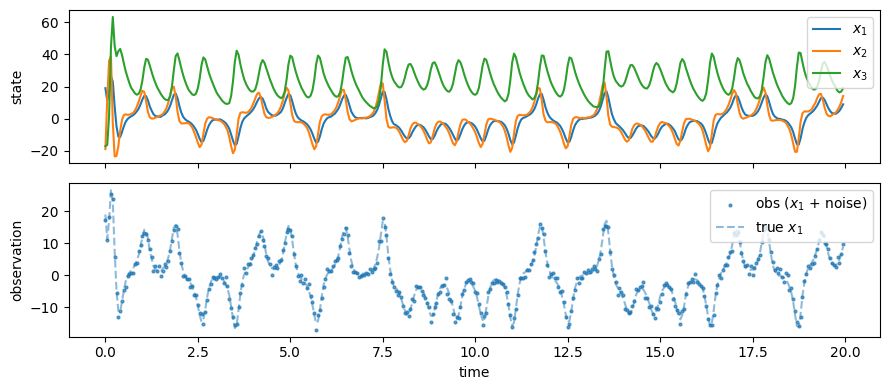

In [3]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 1, figsize=(9, 4), sharex=True)
axes[0].plot(times_arr, states[:, 0], label="$x_1$")
axes[0].plot(times_arr, states[:, 1], label="$x_2$")
axes[0].plot(times_arr, states[:, 2], label="$x_3$")
axes[0].set_ylabel("state")
axes[0].legend(loc="upper right")
axes[1].scatter(times_arr, observations[:, 0], s=4, alpha=0.7, label="obs ($x_1$ + noise)")
axes[1].plot(times_arr, states[:, 0], color="C0", alpha=0.5, ls="--", label="true $x_1$")
axes[1].set_ylabel("observation")
axes[1].set_xlabel("time")
axes[1].legend(loc="upper right")
plt.tight_layout()
plt.show()

## Inference

In [4]:
from dynestyx.filters import ContinuousEnKFConfig

# Define the observed data as a Trajectory
obs_trajectory = Trajectory(times=times_arr, values=observations)

# Define the overall context variable that contains the observed data
ctx = Context(observations=obs_trajectory)
# If we had control inputs, we could also include them in the context
# ctx = Context(observations=obs_trajectory, controls=controls_trajectory)

# Define the data-conditioned, filter-marginalized model
def data_conditioned_model():
    # Tells the model to marginalize over the latent states using a filter
    # Default is Ensemble Kalman Filter (EnKF) for SDEs with linear Gaussian observation model
    config = ContinuousEnKFConfig(warn=False)
    with Filter(config): 
        # Tells the model to condition on the observed data
        with Condition(ctx):
            # Our model
            return l63_model()

# Run NUTS with MCMC. The below is simple numpyro code.
mcmc = MCMC(NUTS(data_conditioned_model), num_warmup=100, num_samples=100)
mcmc.run(jr.PRNGKey(2))

ImportError: cannot import name 'ContinuousEnKFConfig' from 'dynestyx.filters' (/Users/danwaxman/Documents/dynestyx/dynestyx/filters.py)

## Posterior

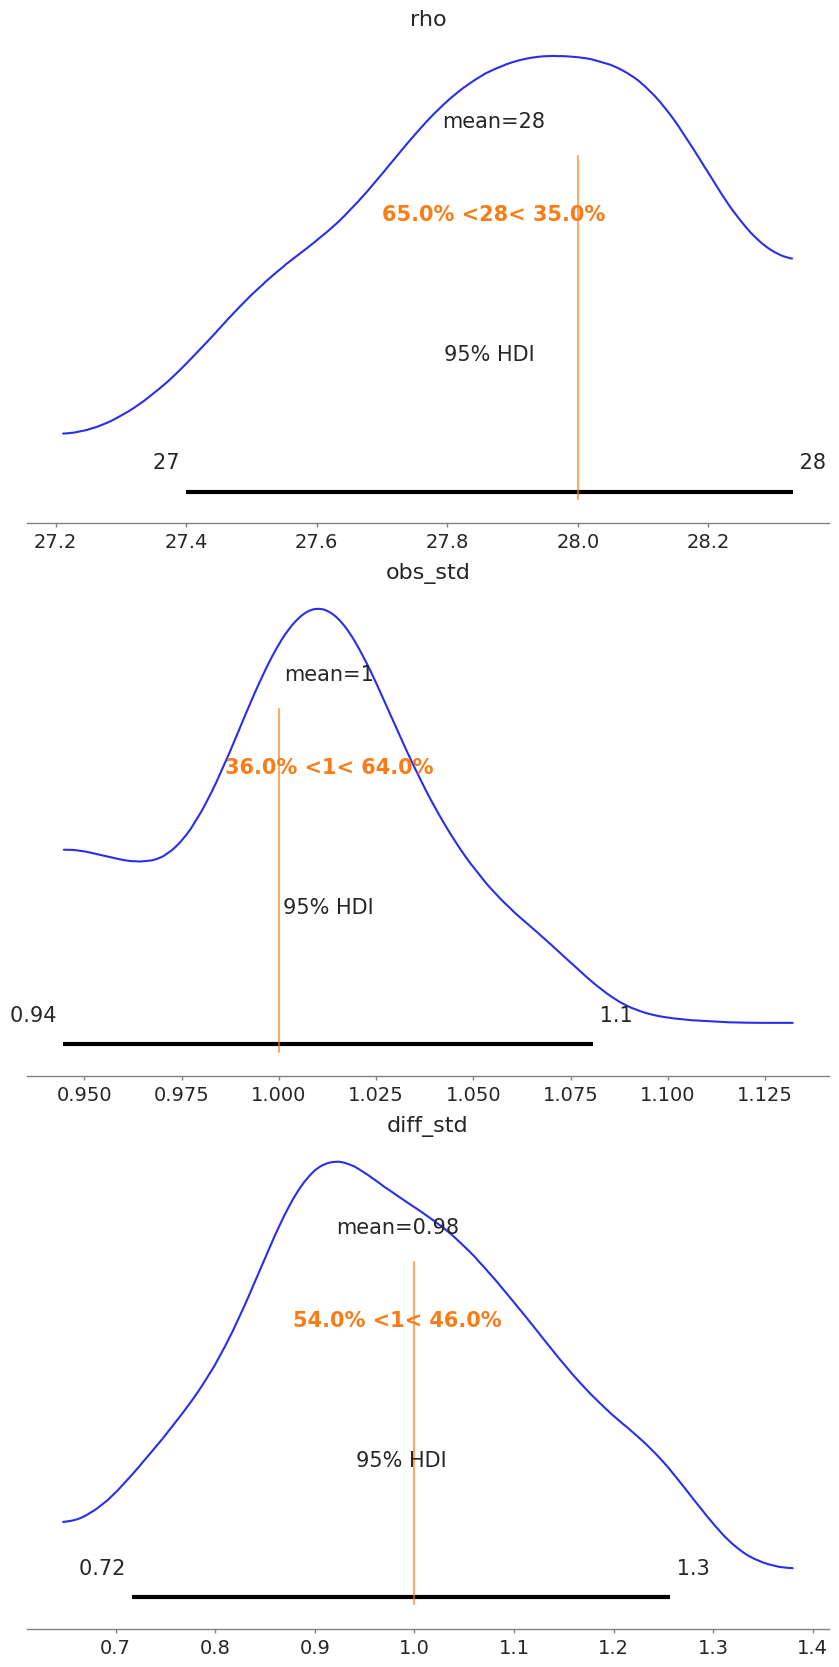

In [ ]:
import arviz as az

posterior = mcmc.get_samples()
az.style.use("arviz-white")
az.plot_posterior(
    posterior,
    grid=(3, 1),
    var_names=["rho", "obs_std", "diff_std"],
    hdi_prob=0.95,
    ref_val=[rho_true, obs_std_true, diff_std_true],
)
plt.show()
